In [1]:
import os
import json
import random
from typing import List, Dict

def write_jsonl_output(directory: str, output_file: str) -> None:
    """
    遍历指定目录及其所有子目录中的 JSON 文件，每个子文件夹随机选择 10 个 JSON 文件，
    并将其信息以 JSON Lines 格式写入到指定的输出文件中。
    
    参数:
    directory (str): JSON 文件所在的根目录路径
    output_file (str): 输出的 JSON Lines 文件路径
    """
    try:
        with open(output_file, 'w', encoding='utf-8') as outfile:
            # 使用 os.walk() 遍历根目录及其所有子目录
            for root, dirs, files in os.walk(directory):
                # 只处理 .json 结尾的文件
                json_files = [file for file in files if file.endswith('.json')]
                
                # 如果 json 文件数量大于 10，随机选择 10 个文件
                if len(json_files) > 10:
                    selected_files = random.sample(json_files, 10)
                else:
                    selected_files = json_files

                # 处理每个被选中的 JSON 文件
                for json_file in selected_files:
                    json_path = os.path.join(root, json_file)
                    
                    try:
                        with open(json_path, 'r', encoding='utf-8') as file:
                            content = json.load(file)

                            # 提取字段
                            folder_name = os.path.basename(root)
                            file_path = json_path
                            tool_name = content.get('name', '')
                            description = content.get('tool_description', '')

                            # 写入 JSON Lines 格式
                            json_line = {
                                'folder_name': folder_name,
                                'file_path': file_path,
                                'tool_name': tool_name,
                                'description': description
                            }
                            outfile.write(json.dumps(json_line, ensure_ascii=False) + '\n')
                    
                    except json.JSONDecodeError as json_error:
                        print(f"文件解析失败: {json_file}, 错误: {json_error}")
                    except FileNotFoundError as fnf_error:
                        print(f"文件未找到: {fnf_error}")
                    except Exception as e:
                        print(f"处理文件 {json_file} 时出错: {e}")

    except FileNotFoundError as fnf_error:
        print(f"目录未找到: {fnf_error}")
    except PermissionError as perm_error:
        print(f"权限不足: {perm_error}")
    except Exception as e:
        print(f"出现错误: {e}")

def load_json_from_jsonl(jsonl_file: str) -> List[Dict]:
    """
    读取 JSON Lines 文件，根据每个记录中的 'file_path' 字段读取对应的 JSON 文件，
    并返回所有 JSON 文件的内容对象列表。
    
    参数:
    jsonl_file (str): 包含 JSON 对象的 JSON Lines 文件路径
    
    返回:
    List[Dict]: 包含所有 JSON 文件内容对象的列表
    """
    json_objects = []

    try:
        with open(jsonl_file, 'r', encoding='utf-8') as infile:
            for line in infile:
                record = json.loads(line)
                file_path = record.get('file_path', '')
                
                if file_path:
                    try:
                        with open(file_path, 'r', encoding='utf-8') as json_file:
                            content = json.load(json_file)
                            json_objects.append(content)
                    
                    except json.JSONDecodeError as json_error:
                        print(f"文件解析失败: {file_path}, 错误: {json_error}")
                    except FileNotFoundError as fnf_error:
                        print(f"文件未找到: {fnf_error}")
                    except Exception as e:
                        print(f"处理文件 {file_path} 时出错: {e}")

    except FileNotFoundError as fnf_error:
        print(f"文件未找到: {fnf_error}")
    except PermissionError as perm_error:
        print(f"权限不足: {perm_error}")
    except Exception as e:
        print(f"出现错误: {e}")

    return json_objects

# 你要遍历的文件夹路径
directory_path = "/Users/caizhuoyue/Desktop/热血毕业/RapidAPIHub-sample/tools"
# 输出的 JSON Lines 文件路径
output_file_path = "/Users/caizhuoyue/Desktop/热血毕业/RapidAPIHub-sample/output.jsonl"

# 调用函数，随机选择每个子文件夹中的 10 个 JSON 文件，并输出到 JSON Lines 文件
write_jsonl_output(directory_path, output_file_path)

# 根据 JSON Lines 文件读取所有 JSON 文件的内容
json_objects = load_json_from_jsonl(output_file_path)
print(json_objects[:2])

[{'product_id': 'api_f1533ee4-2d33-4edc-8244-1f7737f40596', 'tool_description': 'Genius - Song Lyrics, Artists, Albums, Knowledge & More API', 'home_url': 'https://rapidapi.com/Glavier/api/genius-song-lyrics1/', 'name': 'Genius - Song Lyrics', 'title': 'Genius - Song Lyrics', 'pricing': 'FREEMIUM', 'tool_name': 'Genius - Song Lyrics', 'score': {'avgServiceLevel': 100, 'avgLatency': 813, 'avgSuccessRate': 98, 'popularityScore': 9.8, '__typename': 'Score'}, 'host': 'genius-song-lyrics1.p.rapidapi.com', 'api_list': [{'name': 'Song Recommendations', 'url': 'https://genius-song-lyrics1.p.rapidapi.com/song/recommendations/', 'description': 'Song Recommendations', 'method': 'GET', 'required_parameters': [{'name': 'id', 'type': 'STRING', 'description': 'Song ID', 'default': '2396871'}], 'optional_parameters': [{'name': 'text_format', 'type': 'STRING', 'description': 'Format for text bodies related to the document. One or more of `dom`, `plain`, `markdown`, and `html`, separated by commas (defa

In [4]:
from openai import OpenAI
from typing import Optional

def get_chat_response(prompt: str) -> Optional[str]:
    """
    使用 OpenAI API 获取聊天回复。

    参数:
    prompt (str): 要发送到聊天模型的提示语

    返回:
    Optional[str]: 模型生成的回复内容。如果发生错误，返回 None。
    """
    # 初始化 OpenAI 客户端
    try:
        client = OpenAI(
            api_key="sk-H0UFSY3LvO8YBt092HnMfLO6oRHZjbwdwTVucnxRwVEUzZAA",
            base_url="https://api.chatanywhere.tech/v1"
            # base_url="https://api.chatanywhere.cn/v1"
        )
    except Exception as e:
        print(f"初始化 OpenAI 客户端时出错: {e}")
        return None

    # 调用 chat.completions.create 方法
    try:
        response = client.chat.completions.create(
            model="gpt-3.5-turbo",
            response_format={"type": "json_object"},
            messages=[
                {"role": "system", "content": "You are a helpful assistant."},
                {"role": "user", "content": prompt}
            ]
        )
    except Exception as e:
        print(f"调用 OpenAI API 时出错: {e}")
        return None

    # 提取并返回 response 中的 content 字段
    try:
        content = response.choices[0].message.content if response.choices else "No content available"
        return content
    except AttributeError as e:
        print(f"解析 API 响应时出错: {e}")
        return None

In [5]:
import json
import tiktoken
import os
from typing import List, Callable
from datetime import datetime

def count_tokens(text: str, model: str = "gpt-3.5-turbo") -> int:
    """
    计算文本在指定模型中的token数量。

    Args:
        text (str): 需要计算的文本
        model (str): 使用的模型名称，默认是 "gpt-3.5-turbo"

    Returns:
        int: 文本中的token数量
    """
    try:
        encoder = tiktoken.encoding_for_model(model)
    except KeyError as e:
        raise ValueError(f"无效的模型名称: {model}, 错误信息: {e}")
    
    tokens = encoder.encode(text)
    return len(tokens)


def add_timestamp_if_exists(file_path: str) -> str:
    """
    检查文件是否存在，如果存在，则在文件名后添加时间戳。

    Args:
        file_path (str): 原始文件路径

    Returns:
        str: 新的文件路径，如果原始文件存在则带有时间戳
    """
    if os.path.exists(file_path):
        # 提取文件名和扩展名
        base, ext = os.path.splitext(file_path)
        # 获取当前时间戳
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        # 返回带时间戳的文件名
        return f"{base}_{timestamp}{ext}"
    return file_path


def generate_api_prompts_and_save(
    json_objects: List[dict], 
    get_chat_response: Callable[[str], str], 
    output_file: str
) -> None:
    """
    从给定的 JSON 对象中提取 API 信息，生成语义分析的提示，并将结果逐行保存到 .jsonl 文件中。

    Args:
        json_objects (List[dict]): 包含多个工具信息的 JSON 对象列表。
        get_chat_response (Callable[[str], str]): 用于与聊天机器人进行对话并获取响应的函数。
        output_file (str): 输出 .jsonl 文件的路径。
    """
    
    if not json_objects:
        raise ValueError("输入的 json_objects 不能为空")

    GET_SEMANTIC_PROMPT = """
    请帮我从中抽取一些API有关的语义节点，返回一个json list格式的内容。以及点与点之间的关系（节点之间的边）。

    # 具体要求
    1. 抽取的所有节点都需要id（唯一的id）,name（名称）,description（描述信息）,type（节点的类型）还有properties（一个list），包含节点的重要信息。
    2. 节点：语义节点要丰富，语义节点越多越好，并且要有实际意义。比如，查询天气的api可以建立该api与"weather"节点之间的关系
    3. 边：需要有source target label三个字段，source和target都是对应节点的id，然后label用于描述这个关系

    # JSON格式
    你必须按照下列格式输出
    {{"nodes":[],"edges":[]}}
    """

    total_len = len(json_objects)
    results = []

    for index, tool in enumerate(json_objects, start=1):
        try:
            # 构建工具的基本信息
            api_info = (
                f"工具名称：{tool.get('name', '未知')}\n"
                f"工具描述：{tool.get('tool_description', '无描述')}\n"
            )
            
            # 处理较长的API信息
            api_list = tool.get('api_list', [])
            for api in api_list:
                api_str = str(api)
                if count_tokens(api_info + api_str) > 4000 - count_tokens(GET_SEMANTIC_PROMPT):
                    break
                api_info += api_str
            
            # 构建语义分析的提示
            prompt = f"{GET_SEMANTIC_PROMPT}{api_info}"
            
            # 获取聊天机器人的响应
            response_content = get_chat_response(prompt)
            
            # 将结果追加到列表
            json_record = {
                "tool_name": tool.get("name", "未知"),
                "api_info": api_list,
                "semantic_response": response_content
            }
            results.append(json.dumps(json_record, ensure_ascii=False))
            print(f"{index}/{total_len} - 已处理工具: {tool.get('name', '未知')}")

        except KeyError as e:
            print(f"工具 {tool.get('name', '未知')} 缺少必要字段: {e}")
        except Exception as exc:
            print(f"处理工具 {tool.get('name', '未知')} 时发生错误: {exc}")

    # 检查文件是否存在，并添加时间戳（如果需要）
    output_file = add_timestamp_if_exists(output_file)

    # 将所有结果一次性写入文件
    try:
        with open(output_file, 'w', encoding='utf-8') as outfile:
            outfile.write('\n'.join(results) + '\n')
        print(f"结果成功写入 {output_file}")
    except IOError as e:
        raise RuntimeError(f"无法写入文件 {output_file}: {e}")


# 示例：调用 generate_api_prompts_and_save 函数
output_file_path = 'kg_small_batch.jsonl'
generate_api_prompts_and_save(json_objects, get_chat_response, output_file_path)

1/87 - 已处理工具: Miza
2/87 - 已处理工具: K-POP
3/87 - 已处理工具: Bandamp Downloader API
4/87 - 已处理工具: YourVinylStore
5/87 - 已处理工具: VkoorSound
6/87 - 已处理工具: Spotify Web
7/87 - 已处理工具: Billboard
8/87 - 已处理工具: LANDR Mastering v1
9/87 - 已处理工具: MyAPI
10/87 - 已处理工具: melodyn
11/87 - 已处理工具: a56219609685dd9033d060cdbb60093c
12/87 - 已处理工具: Minecraft Servers List
13/87 - 已处理工具: Valorant Weapons
14/87 - 已处理工具: Dungeons and Dragon 5e
15/87 - 已处理工具: Evosis's Game Database
16/87 - 已处理工具: Weeby
17/87 - 已处理工具: MCAPI
18/87 - 已处理工具: Trackmania
19/87 - 已处理工具: Word Tree
20/87 - 已处理工具: taboo-api
21/87 - 已处理工具: NameForge
22/87 - 已处理工具: The Dozen - The Yo Mamsa Roast API
23/87 - 已处理工具: Meme Generator_v2
24/87 - 已处理工具: Dad Jokes by API-Ninjas
25/87 - 已处理工具: The Love Calculator
26/87 - 已处理工具: PAPI - PornstarsAPI
27/87 - 已处理工具: retrieve info
28/87 - 已处理工具: Game of Thrones
29/87 - 已处理工具: Humor-Jokes-and-Memes
30/87 - 已处理工具: Jokes by API-Ninjas
31/87 - 已处理工具: Health Calculator API
32/87 - 已处理工具: Scoring Tables API
33/87 - 已处理工

In [2]:
import json

def extract_apis(json_objects: list) -> dict:
    """
    从json_objects列表中提取每个工具的api_list，并将其存储在一个字典中。
    
    Args:
        json_objects (list): 包含多个工具信息的json对象列表
    
    Returns:
        dict: 包含API名称与对应API信息的字典
    """
    api_map = {}  # 用于存储 API 名称和其对应的 JSON 对象
    
    for tool in json_objects:
        # 检查每个工具是否包含 "api_list" 键
        if "api_list" in tool:
            try:
                # 遍历该工具的 API 列表
                for api in tool["api_list"]:
                    api_name = api.get("name", "Unknown API")  # 取得API名称，若无名称则使用"Unknown API"
                    api_map[api_name] = api  # 将 API 名称和其对应 JSON 对象存入字典
            except KeyError as e:
                print(f"在工具 '{tool.get('name', 'Unknown Tool')}' 中找不到预期键: {e}")
            except Exception as exc:
                print(f"处理工具 '{tool.get('name', 'Unknown Tool')}' 的 API 时出错: {exc}")
    
    return api_map

def count_apis(api_map: dict) -> int:
    """
    统计 API 字典中的 API 数量。
    
    Args:
        api_map (dict): 包含API名称与其信息的字典
    
    Returns:
        int: API 的数量
    """
    return len(api_map)
# 提取 API 并统计
api_map = extract_apis(json_objects)
print(f"提取的API数量: {count_apis(api_map)}")

# 输出存储的 API 列表
for api_name, api_info in api_map.items():
    print(f"API 名称: {api_name}")

提取的API数量: 335
API 名称: Song Recommendations
API 名称: Song Lyrics
API 名称: Videos
API 名称: User Contributions (unreviewed annotations)
API 名称: Annotation Details
API 名称: User Contributions (transcriptions)
API 名称: User Contributions (suggestions)
API 名称: User Contributions (q&a)
API 名称: User Contributions (pyongs)
API 名称: User Contributions (articles)
API 名称: User Contributions (annotations)
API 名称: User Contributions (all)
API 名称: User Following
API 名称: User Followers
API 名称: User Accomplishments
API 名称: User Details
API 名称: Leaderboard
API 名称: Web Page Referents
API 名称: Chart: Albums
API 名称: Chart: Songs
API 名称: Annotation Versions
API 名称: Album Comments
API 名称: Artist Leaderboard
API 名称: Artist Activity
API 名称: Web Page Lookup
API 名称: Referents
API 名称: Album Appearances
API 名称: Artist Songs
API 名称: Artist Albums
API 名称: Artist Details
API 名称: Search
API 名称: Song Comments
API 名称: Song Details
API 名称: Album Details
API 名称: Multi Search
API 名称: Chart: Referents
API 名称: Chart: Artists
API 名称

In [6]:
import json

def parse_jsonl_and_merge_nodes_edges(file_path: str):
    """
    读取JSONL文件，解析并合并所有行中的semantic_response字段的nodes和edges。
    
    Args:
        file_path (str): JSONL文件的路径。
    
    Returns:
        Tuple[List[dict], List[dict]]: 去重后的nodes和edges列表。
    """
    all_nodes = []
    all_edges = []
    nodes_set = set()
    edges_set = set()

    # 打开并逐行读取jsonl文件
    with open(file_path, 'r', encoding='utf-8') as file:
        for line in file:
            try:
                # 解析每一行，获取semantic_response并转换为JSON对象
                record = json.loads(line.strip())
                semantic_response = record.get('semantic_response', '{}')
                response_data = json.loads(semantic_response)
                
                # 获取nodes和edges
                nodes = response_data.get('nodes', [])
                edges = response_data.get('edges', [])
                
                # 去重合并nodes
                for node in nodes:
                    node_tuple = (node['name'], node['description'])  # 根据name和description去重
                    if node_tuple not in nodes_set:
                        nodes_set.add(node_tuple)
                        all_nodes.append(node)
                
                # 去重合并edges
                for edge in edges:
                    edge_tuple = (edge['source'], edge['target'], edge['label'])  # 根据source, target, label去重
                    if edge_tuple not in edges_set:
                        edges_set.add(edge_tuple)
                        all_edges.append(edge)

            except json.JSONDecodeError as e:
                print(f"解析JSON行失败: {e}")
            except Exception as e:
                print(f"处理行时发生错误: {e}")

    return all_nodes, all_edges


# 指定输入文件路径
jsonl_file_path = "kg_small_batch.jsonl"

# 调用函数并获取去重后的nodes和edges
nodes, edges = parse_jsonl_and_merge_nodes_edges(jsonl_file_path)

# 打印去重后的nodes和edges
print("合并去重后的nodes:")
for node in nodes:
    print(node)

print("\n合并去重后的edges:")
for edge in edges:
    print(edge)


处理行时发生错误: the JSON object must be str, bytes or bytearray, not NoneType
处理行时发生错误: the JSON object must be str, bytes or bytearray, not NoneType
处理行时发生错误: the JSON object must be str, bytes or bytearray, not NoneType
处理行时发生错误: the JSON object must be str, bytes or bytearray, not NoneType
处理行时发生错误: the JSON object must be str, bytes or bytearray, not NoneType
处理行时发生错误: the JSON object must be str, bytes or bytearray, not NoneType
处理行时发生错误: the JSON object must be str, bytes or bytearray, not NoneType
处理行时发生错误: the JSON object must be str, bytes or bytearray, not NoneType
处理行时发生错误: the JSON object must be str, bytes or bytearray, not NoneType
处理行时发生错误: the JSON object must be str, bytes or bytearray, not NoneType
处理行时发生错误: the JSON object must be str, bytes or bytearray, not NoneType
处理行时发生错误: the JSON object must be str, bytes or bytearray, not NoneType
处理行时发生错误: the JSON object must be str, bytes or bytearray, not NoneType
合并去重后的nodes:
{'name': 'myPlayvv', 'description': 'Music sharing 

处理行时发生错误: the JSON object must be str, bytes or bytearray, not NoneType
处理行时发生错误: the JSON object must be str, bytes or bytearray, not NoneType
处理行时发生错误: the JSON object must be str, bytes or bytearray, not NoneType
处理行时发生错误: the JSON object must be str, bytes or bytearray, not NoneType
处理行时发生错误: the JSON object must be str, bytes or bytearray, not NoneType
处理行时发生错误: the JSON object must be str, bytes or bytearray, not NoneType
处理行时发生错误: the JSON object must be str, bytes or bytearray, not NoneType
处理行时发生错误: the JSON object must be str, bytes or bytearray, not NoneType
处理行时发生错误: the JSON object must be str, bytes or bytearray, not NoneType
处理行时发生错误: the JSON object must be str, bytes or bytearray, not NoneType
处理行时发生错误: the JSON object must be str, bytes or bytearray, not NoneType
处理行时发生错误: the JSON object must be str, bytes or bytearray, not NoneType
处理行时发生错误: the JSON object must be str, bytes or bytearray, not NoneType


/Users/caizhuoyue/miniconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 30693 (\N{CJK UNIFIED IDEOGRAPH-77E5}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/caizhuoyue/miniconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 35782 (\N{CJK UNIFIED IDEOGRAPH-8BC6}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/caizhuoyue/miniconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 22270 (\N{CJK UNIFIED IDEOGRAPH-56FE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/caizhuoyue/miniconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 35889 (\N{CJK UNIFIED IDEOGRAPH-8C31}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


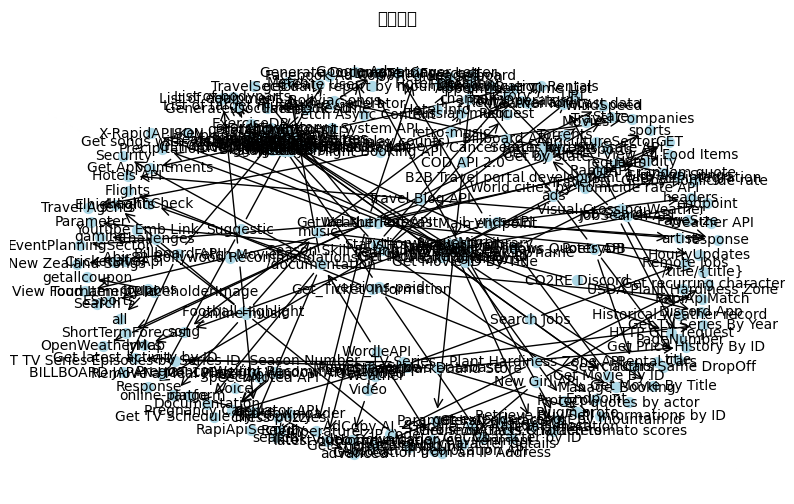

In [3]:
import json
import networkx as nx
import matplotlib.pyplot as plt

def parse_jsonl_and_merge_nodes_edges(file_path: str):
    """
    读取JSONL文件，解析并合并所有行中的semantic_response字段的nodes和edges。
    
    Args:
        file_path (str): JSONL文件的路径。
    
    Returns:
        Tuple[List[dict], List[dict]]: 去重后的nodes和edges列表。
    """
    all_nodes = []
    all_edges = []
    nodes_set = set()
    edges_set = set()

    # 打开并逐行读取jsonl文件
    with open(file_path, 'r', encoding='utf-8') as file:
        for line in file:
            try:
                # 解析每一行，获取semantic_response并转换为JSON对象
                record = json.loads(line.strip())
                semantic_response = record.get('semantic_response', '{}')
                response_data = json.loads(semantic_response)
                
                # 获取nodes和edges
                nodes = response_data.get('nodes', [])
                edges = response_data.get('edges', [])
                
                # 去重合并nodes
                for node in nodes:
                    node_tuple = (node['name'], node['description'])  # 根据name和description去重
                    if node_tuple not in nodes_set:
                        nodes_set.add(node_tuple)
                        all_nodes.append(node)
                
                # 去重合并edges
                for edge in edges:
                    edge_tuple = (edge['source'], edge['target'], edge['label'])  # 根据source, target, label去重
                    if edge_tuple not in edges_set:
                        edges_set.add(edge_tuple)
                        all_edges.append(edge)

            except json.JSONDecodeError as e:
                print(f"解析JSON行失败: {e}")
            except Exception as e:
                print(f"处理行时发生错误: {e}")

    return all_nodes, all_edges

def plot_knowledge_graph(nodes, edges):
    """
    绘制知识图谱，基于传入的nodes和edges。

    Args:
        nodes (List[dict]): 节点列表。
        edges (List[dict]): 边列表。
    """
    # 初始化一个有向图
    G = nx.DiGraph()

    # 添加节点到图中
    for node in nodes:
        G.add_node(node['name'], description=node['description'])

    # 添加边到图中
    for edge in edges:
        G.add_edge(edge['source'], edge['target'])

    # 设置布局
    pos = nx.spring_layout(G)

    # 绘制节点，减小节点大小
    plt.figure(figsize=(10, 6))
    nx.draw_networkx_nodes(G, pos, node_size=50, node_color='lightblue')  # 节点变小

    # 绘制节点标签
    nx.draw_networkx_labels(G, pos, font_size=10, font_family='sans-serif')

    # 绘制边，不显示边的label
    nx.draw_networkx_edges(G, pos, edgelist=G.edges(), arrowstyle='->', arrowsize=15)

    # 去掉边标签
    # edge_labels = nx.get_edge_attributes(G, 'label') # 不需要边标签了

    # 显示图谱
    plt.title("知识图谱")
    plt.axis('off')  # 关闭坐标轴
    plt.show()

# 指定输入文件路径
jsonl_file_path = "kg_small_batch.jsonl"

# 调用函数并获取去重后的nodes和edges
nodes, edges = parse_jsonl_and_merge_nodes_edges(jsonl_file_path)

# 绘制知识图谱
plot_knowledge_graph(nodes, edges)

In [10]:
import csv
import os

def save_to_csv(nodes, edges, nodes_file: str, edges_file: str):
    """
    将nodes和edges分别保存为CSV文件。
    
    Args:
        nodes (List[dict]): 节点列表。
        edges (List[dict]): 边列表。
        nodes_file (str): 保存节点的CSV文件路径。
        edges_file (str): 保存边的CSV文件路径。
    """
    # 保存节点
    with open(nodes_file, 'w', newline='', encoding='utf-8') as f:
        writer = csv.writer(f)
        writer.writerow(['name', 'description'])  # 表头
        for node in nodes:
            writer.writerow([node['name'], node['description']])
    
    # 保存边
    with open(edges_file, 'w', newline='', encoding='utf-8') as f:
        writer = csv.writer(f)
        writer.writerow(['source', 'target', 'relationship'])  # 表头
        for edge in edges:
            writer.writerow([edge['source'], edge['target'], edge['label']])

# 指定CSV文件路径
nodes_csv = 'nodes.csv'
edges_csv = 'edges.csv'

# 调用函数保存数据为CSV
save_to_csv(nodes, edges, nodes_csv, edges_csv)

print(f"Nodes saved to {os.path.abspath(nodes_csv)}")
print(f"Edges saved to {os.path.abspath(edges_csv)}")


Nodes saved to /Users/caizhuoyue/Desktop/热血毕业/nodes.csv
Edges saved to /Users/caizhuoyue/Desktop/热血毕业/edges.csv


In [7]:
%pip install pandas networkx python-louvain matplotlib

"""
此文件使用Leiden算法对知识图谱进行聚类，并打印每个簇的节点。
"""

import pandas as pd
import networkx as nx
import community as community_louvain
import matplotlib.pyplot as plt

def load_data(nodes_file: str, edges_file: str) -> (pd.DataFrame, pd.DataFrame):
    """
    加载节点和边的数据。
    
    :param nodes_file: 节点CSV文件路径
    :param edges_file: 边CSV文件路径
    :return: 节点和边的DataFrame
    """
    nodes = pd.read_csv(nodes_file)
    edges = pd.read_csv(edges_file)
    return nodes, edges

def create_graph(nodes: pd.DataFrame, edges: pd.DataFrame) -> nx.Graph:
    """
    创建图对象。
    
    :param nodes: 节点DataFrame
    :param edges: 边DataFrame
    :return: NetworkX图对象
    """
    G = nx.Graph()
    for _, row in edges.iterrows():
        G.add_edge(row['source'], row['target'], relationship=row['relationship'])
    return G

def apply_leiden_algorithm(G: nx.Graph) -> dict:
    """
    应用Leiden算法进行聚类。
    
    :param G: NetworkX图对象
    :return: 节点与簇的映射
    """
    partition = community_louvain.best_partition(G)
    return partition

def print_clusters(partition: dict, nodes: pd.DataFrame):
    """
    打印每个簇的节点。
    
    :param partition: 节点与簇的映射
    :param nodes: 节点DataFrame
    """
    clusters = {}
    for node, cluster in partition.items():
        if cluster not in clusters:
            clusters[cluster] = []
        clusters[cluster].append(node)

    for cluster_id, cluster_nodes in clusters.items():
        print(f"簇 {cluster_id}: {cluster_nodes}")

if __name__ == "__main__":
    # 设置文件路径
    NODES_FILE = 'nodes.csv'
    EDGES_FILE = 'edges.csv'
    
    try:
        # 加载数据
        nodes_df, edges_df = load_data(NODES_FILE, EDGES_FILE)
        
        # 创建图
        G = create_graph(nodes_df, edges_df)
        
        # 应用Leiden算法
        partition = apply_leiden_algorithm(G)
        
        # 打印每个簇的节点
        print_clusters(partition, nodes_df)
        
    except FileNotFoundError as e:
        print(f"文件未找到: {e}")
    except pd.errors.EmptyDataError as e:
        print(f"数据为空: {e}")
    except Exception as e:
        print(f"发生错误: {e}")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.6/204.6 kB 666.6 kB/s eta 0:00:00a 0:00:01
  Preparing metadata (setup.py) ... done
  Created wheel for python-louvain: filename=python_louvain-0.16-py3-none-any.whl size=9389 sha256=fba48dd2d0c69371e2950f4018e24f7d2e705ffa78cf35e2251fc889c0d64970
  Stored in directory: /Users/caizhuoyue/Library/Caches/pip/wheels/40/f1/e3/485b698c520fa0baee1d07897abc7b8d6479b7d199ce96f4af
Successfully built python-louvain
Note: you may need to restart the kernel to use updated packages.
簇 8: ['myPlayvv', 'API', 'Protocol', 'Plugin.proto', 'GET', 'requests', 'X-RapidAPI-Key', 'X-RapidAPI-Host', 'COD API 2.0', 'Leaderboard', 'Workout Planner', 'Parameters', 'CO2RE Discord', 'Discord App', 'HTTP GET request', 'RapidAPI', 'JSON', 'Python Requests Library', 'ads', 'endpoint', 'MagicMirror', 'TravelPD', 'B2B Travel portal development with API integration', 'Turkey Public Holidays']
簇 2: ['music', 'L-yrics API', 'Main endpoint', 'song', 'artist', 'querystring', '

In [8]:
"""
此文件使用Louvain算法对知识图谱进行聚类，并打印每个簇的节点。
"""

import pandas as pd
import networkx as nx
import community as community_louvain

def load_data(nodes_file: str, edges_file: str) -> (pd.DataFrame, pd.DataFrame):
    """
    加载节点和边的数据。
    
    :param nodes_file: 节点CSV文件路径
    :param edges_file: 边CSV文件路径
    :return: 节点和边的DataFrame
    """
    nodes = pd.read_csv(nodes_file)
    edges = pd.read_csv(edges_file)
    return nodes, edges

def create_graph(nodes: pd.DataFrame, edges: pd.DataFrame) -> nx.Graph:
    """
    创建图对象。
    
    :param nodes: 节点DataFrame
    :param edges: 边DataFrame
    :return: NetworkX图对象
    """
    G = nx.Graph()
    for _, row in edges.iterrows():
        G.add_edge(row['source'], row['target'], relationship=row['relationship'])
    return G

def apply_louvain_algorithm(G: nx.Graph, resolution: float = 1.0) -> dict:
    """
    应用Louvain算法进行聚类。
    
    :param G: NetworkX图对象
    :param resolution: 分辨率参数，调节簇的数量
    :return: 节点与簇的映射
    """
    partition = community_louvain.best_partition(G, resolution=resolution)
    return partition

def print_clusters(partition: dict, nodes: pd.DataFrame):
    """
    打印每个簇的节点。
    
    :param partition: 节点与簇的映射
    :param nodes: 节点DataFrame
    """
    clusters = {}
    for node, cluster in partition.items():
        if cluster not in clusters:
            clusters[cluster] = []
        clusters[cluster].append(node)

    for cluster_id, cluster_nodes in clusters.items():
        print(f"簇 {cluster_id}: {cluster_nodes}")

if __name__ == "__main__":
    # 设置文件路径
    NODES_FILE = 'nodes.csv'
    EDGES_FILE = 'edges.csv'
    
    try:
        # 加载数据
        nodes_df, edges_df = load_data(NODES_FILE, EDGES_FILE)
        
        # 创建图
        G = create_graph(nodes_df, edges_df)
        
        # 应用Louvain算法，调整分辨率
        RESOLUTION = 0.5  # 可以尝试不同的分辨率值，例如0.5, 1.0, 2.0
        partition = apply_louvain_algorithm(G, resolution=RESOLUTION)
        
        # 打印每个簇的节点
        print_clusters(partition, nodes_df)
        
    except FileNotFoundError as e:
        print(f"文件未找到: {e}")
    except pd.errors.EmptyDataError as e:
        print(f"数据为空: {e}")
    except Exception as e:
        print(f"发生错误: {e}")


簇 0: ['myPlayvv', 'API', 'Protocol', 'Plugin.proto', 'X-RapidAPI-Key', 'X-RapidAPI-Host', 'COD API 2.0', 'Leaderboard', 'Workout Planner', 'Parameters', 'CO2RE Discord', 'Discord App', 'HTTP GET request', 'JSON', 'Python Requests Library', 'endpoint', 'MagicMirror', 'Turkey Public Holidays']
簇 9: ['music', 'online-music', 'retro-music', 'Russian-music', 'chanson', 'online-platform']
簇 3: ['L-yrics API', 'Main endpoint', 'song', 'artist', 'querystring', 'headers', 'response', 'lyrics', 'JobSearch API', 'Job Search', 'SearchQuery', 'PageSize', 'PageNumber']
簇 5: ['SpeechNoted API', 'Get Voices', 'Voice']
簇 6: ['Billboard API', 'Bolivia Songs', 'Slovakia Songs']
簇 23: ['Rojmusic', 'weather', 'melodyn', 'Get songs with ALL metadata and stats (play counts)', 'Get Top 50 indie songs', 'Search indie songs by filters', 'Billboard-API', 'New Zealand Songs', 'BILLBOARD JAPAN HOT 100', 'getAllQuotes', 'getStationByCountry', 'Search Coming Soon Games', 'Search On Sale Games', 'Tournaments', 'Get M